In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.preprocessing.image import ImageDataGenerator

C:\Users\bhava\OneDrive\Desktop\Advanced_AI_Medical_Platform\venv\lib\site-packages\google\api_core\_python_version_support.py:242: FutureWarning: You are using a non-supported Python version (3.9.9). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)
C:\Users\bhava\OneDrive\Desktop\Advanced_AI_Medical_Platform\venv\lib\site-packages\google\auth\__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
C:\Users\bhava\OneDrive\Desktop\Advanced_AI_Medical_Platform\venv\lib\site-packages\google\oauth2\__init__.py:40: FutureWarning: You are

In [2]:
train_dir = "../chest_xray/train"
test_dir = "../chest_xray/test"

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2
)

In [4]:
#Create Training & Validation Generators
train_generator = train_datagen.flow_from_directory(
    directory=train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset="training",
    shuffle=True
)

Found 4173 images belonging to 2 classes.


In [5]:
#Create the Validation Generator
validation_generator = train_datagen.flow_from_directory(
    directory=train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

Found 1043 images belonging to 2 classes.


In [6]:
#Create the Test Generator
test_datagen = ImageDataGenerator(
    rescale=1.0/255
)

test_generator = test_datagen.flow_from_directory(
    directory=test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 624 images belonging to 2 classes.


In [7]:
print(train_generator.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


In [8]:
images, labels = next(train_generator)

In [9]:
print("Images Shape :", images.shape)
print("Labels Shape :", labels.shape)

Images Shape : (32, 224, 224, 3)
Labels Shape : (32,)


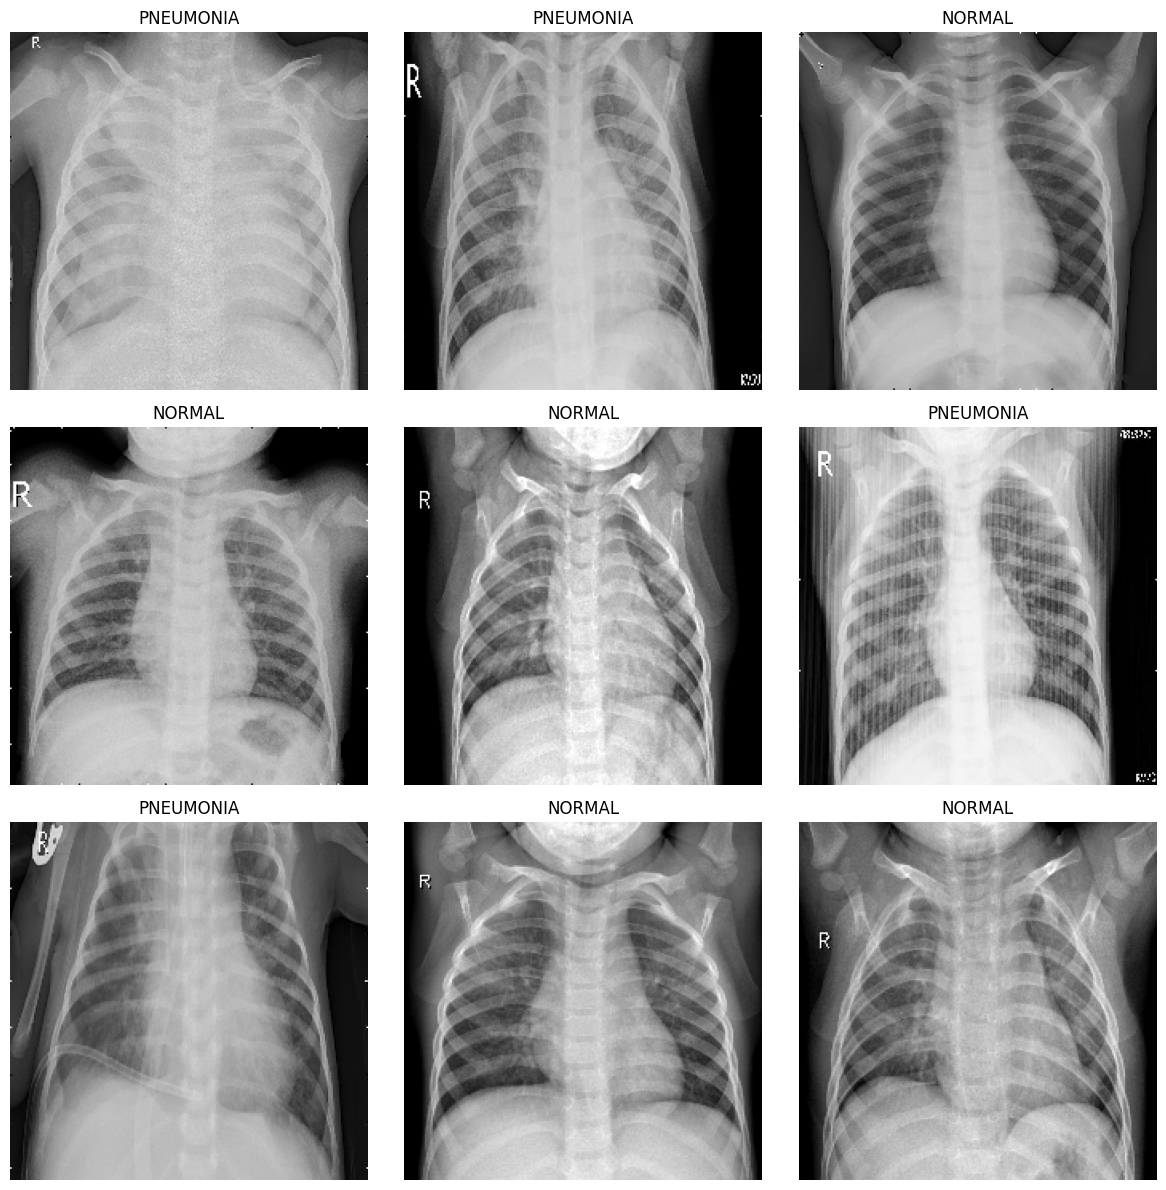

In [10]:
plt.figure(figsize=(12, 12))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    plt.imshow(images[i])

    if labels[i] == 0:
        plt.title("NORMAL")
    else:
        plt.title("PNEUMONIA")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
print("Minimum Pixel Value:", images.min())
print("Maximum Pixel Value:", images.max())

Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0
